# Notebook 03 — LUAD Python Data Validation (v3)

This notebook loads the analysis-ready TCGA-LUAD cohort produced by the R cleaning pipeline (`R/07_clean_luad.R`) and performs a basic data validation in Python. It mirrors `notebooks/01_python_data_check.ipynb` (BRCA) for direct comparability.

The goals are to:

1. Confirm the dataset dimensions and variable types.
2. Quantify missingness across all columns.
3. Inspect the distributions of key variables.
4. Load and display the multi-cancer comparison outputs from the R pipeline.

**Input:** `data/processed/luad_survival_clean.csv`  
**Produced by:** `R/07_clean_luad.R`  
**Comparison outputs produced by:** `R/11_multicancer_comparison.R`

## 1. Load the cleaned LUAD cohort

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR = Path("../data/processed")
FIG_DIR  = Path("../figures")

df = pd.read_csv(DATA_DIR / "luad_survival_clean.csv")

print("Shape:", df.shape)
display(df.head())
display(df.dtypes)

Shape: (509, 12)


,patient_id,cancer_type,age,gender,race,histological_type,stage_raw,os_event,os_time_days,os_time_months,stage_group,age_group
0,TCGA-05-4245,LUAD,81.0,MALE,NaN,Lung Adenocarcinoma,Stage IIIA,0,730,23.981603,Stage III,65+
1,TCGA-05-4249,LUAD,67.0,MALE,NaN,Lung Adenocarcinoma,Stage IB,0,1523,50.032852,Stage I,65+
2,TCGA-05-4250,LUAD,79.0,FEMALE,NaN,Lung Adenocarcinoma,Stage IIIA,1,121,3.975033,Stage III,65+
3,TCGA-05-4382,LUAD,68.0,MALE,NaN,Lung Adenocarcinoma,Stage IB,0,607,19.940867,Stage I,65+
4,TCGA-05-4384,LUAD,66.0,MALE,NaN,Lung Adenocarcinoma,Stage IIIA,0,426,13.994744,Stage III,65+


patient_id               str
cancer_type              str
age                  float64
gender                   str
race                     str
histological_type        str
stage_raw                str
os_event               int64
os_time_days           int64
os_time_months       float64
stage_group              str
age_group                str
dtype: object

## 2. Missingness summary

In [2]:
missing = (
    df.isnull()
    .sum()
    .rename("n_missing")
    .to_frame()
    .assign(pct_missing=lambda x: (100 * x["n_missing"] / len(df)).round(1))
    .sort_values("n_missing", ascending=False)
)
display(missing)

,n_missing,pct_missing
race,49,9.6
age,10,2.0
age_group,10,2.0
stage_group,8,1.6
stage_raw,1,0.2
gender,0,0.0
patient_id,0,0.0
cancer_type,0,0.0
os_event,0,0.0
histological_type,0,0.0


## 3. Key variable distributions

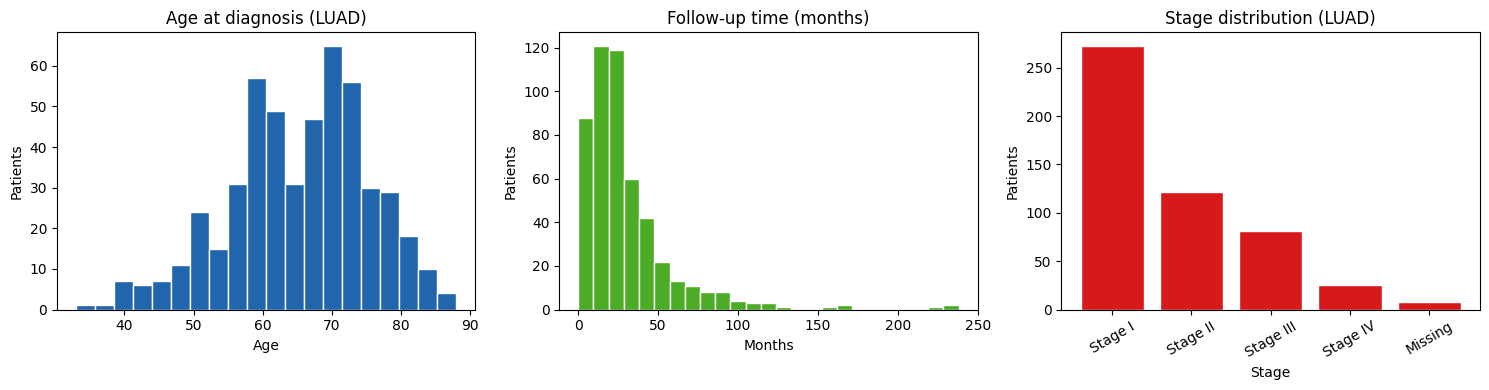

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
axes[0].hist(df["age"].dropna(), bins=20, color="#2166ac", edgecolor="white")
axes[0].set_title("Age at diagnosis (LUAD)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Patients")

# Follow-up distribution
axes[1].hist(df["os_time_months"].dropna(), bins=25, color="#4dac26", edgecolor="white")
axes[1].set_title("Follow-up time (months)")
axes[1].set_xlabel("Months")
axes[1].set_ylabel("Patients")

# Stage distribution
# Stage distribution -- fillna keeps index all-string
stage_counts = df["stage_group"].fillna("Missing").value_counts()
axes[2].bar(stage_counts.index, stage_counts.values, color="#d7191c", edgecolor="white")
axes[2].set_title("Stage distribution (LUAD)")
axes[2].set_xlabel("Stage")
axes[2].set_ylabel("Patients")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 4. Survival endpoint summary

In [4]:
n = len(df)
n_events = int(df["os_event"].sum())
event_rate = 100 * df["os_event"].mean()
median_fu = df["os_time_months"].median()
median_age = df["age"].median()

summary = pd.DataFrame({
    "Metric": ["Patients", "OS events", "Event rate (%)", "Median follow-up (months)", "Median age"],
    "Value":  [n, n_events, f"{event_rate:.1f}", f"{median_fu:.1f}", f"{median_age:.1f}"]
})
display(summary)

,Metric,Value
0,Patients,509
1,OS events,183
2,Event rate (%),36.0
3,Median follow-up (months),21.6
4,Median age,66.0


## 5. Multi-cancer comparison

The outputs below are produced by `R/11_multicancer_comparison.R` and require the BRCA pipeline (scripts 01–06) and the LUAD pipeline (scripts 07–10) to have been run first.

In [5]:
cohort_comparison_path = DATA_DIR / "multicancer_cohort_comparison.csv"

if cohort_comparison_path.exists():
    mc_cohort = pd.read_csv(cohort_comparison_path)
    display(mc_cohort)
else:
    print("multicancer_cohort_comparison.csv not found. Run R/11_multicancer_comparison.R first.")

,cancer_type,n_patients,n_os_events,os_event_rate_pct,median_follow_up_months,median_age,n_missing_stage
0,TCGA-BRCA,1083,151,13.9,28.3,58,24
1,TCGA-LUAD,509,183,36.0,21.6,66,8


In [6]:
cox_comparison_path = DATA_DIR / "multicancer_cox_results.csv"

if cox_comparison_path.exists():
    mc_cox = pd.read_csv(cox_comparison_path)
    display(mc_cox)
else:
    print("multicancer_cox_results.csv not found. Run R/11_multicancer_comparison.R first.")

,cancer_type,term,term_label,estimate,conf.low,conf.high,p.value
0,TCGA-BRCA,age,"Age, per year",1.036,1.022,1.049,1.800000e-07
1,TCGA-BRCA,stage_groupStage II,Stage II vs I,1.797,1.036,3.116,3.710000e-02
2,TCGA-BRCA,stage_groupStage III,Stage III vs I,3.614,2.027,6.443,1.330000e-05
3,TCGA-BRCA,stage_groupStage IV,Stage IV vs I,12.083,5.960,24.496,4.810000e-12
4,TCGA-LUAD,age,"Age, per year",1.009,0.994,1.024,2.570000e-01
5,TCGA-LUAD,stage_groupStage II,Stage II vs I,2.282,1.583,3.288,9.720000e-06
6,TCGA-LUAD,stage_groupStage III,Stage III vs I,3.228,2.200,4.737,2.120000e-09
7,TCGA-LUAD,stage_groupStage IV,Stage IV vs I,3.710,2.136,6.445,3.250000e-06


BRCA vs LUAD — Kaplan-Meier comparison


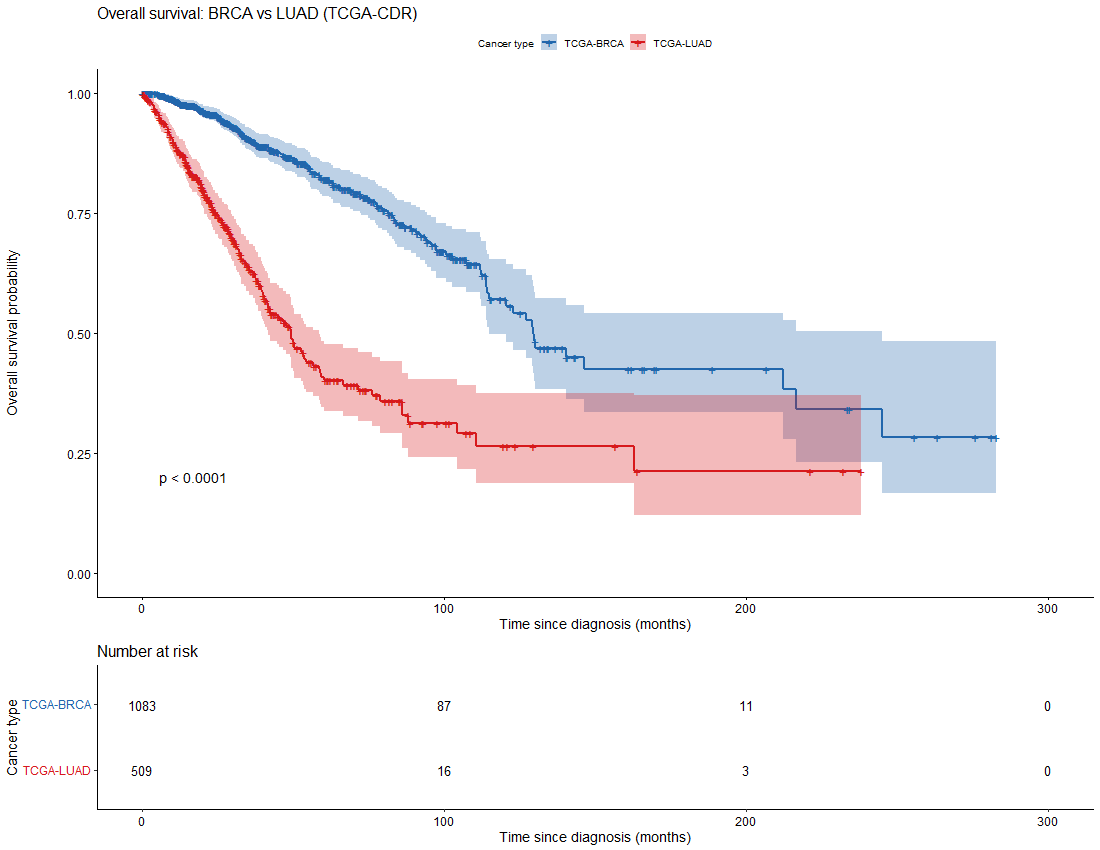

BRCA vs LUAD — Cox forest plot comparison


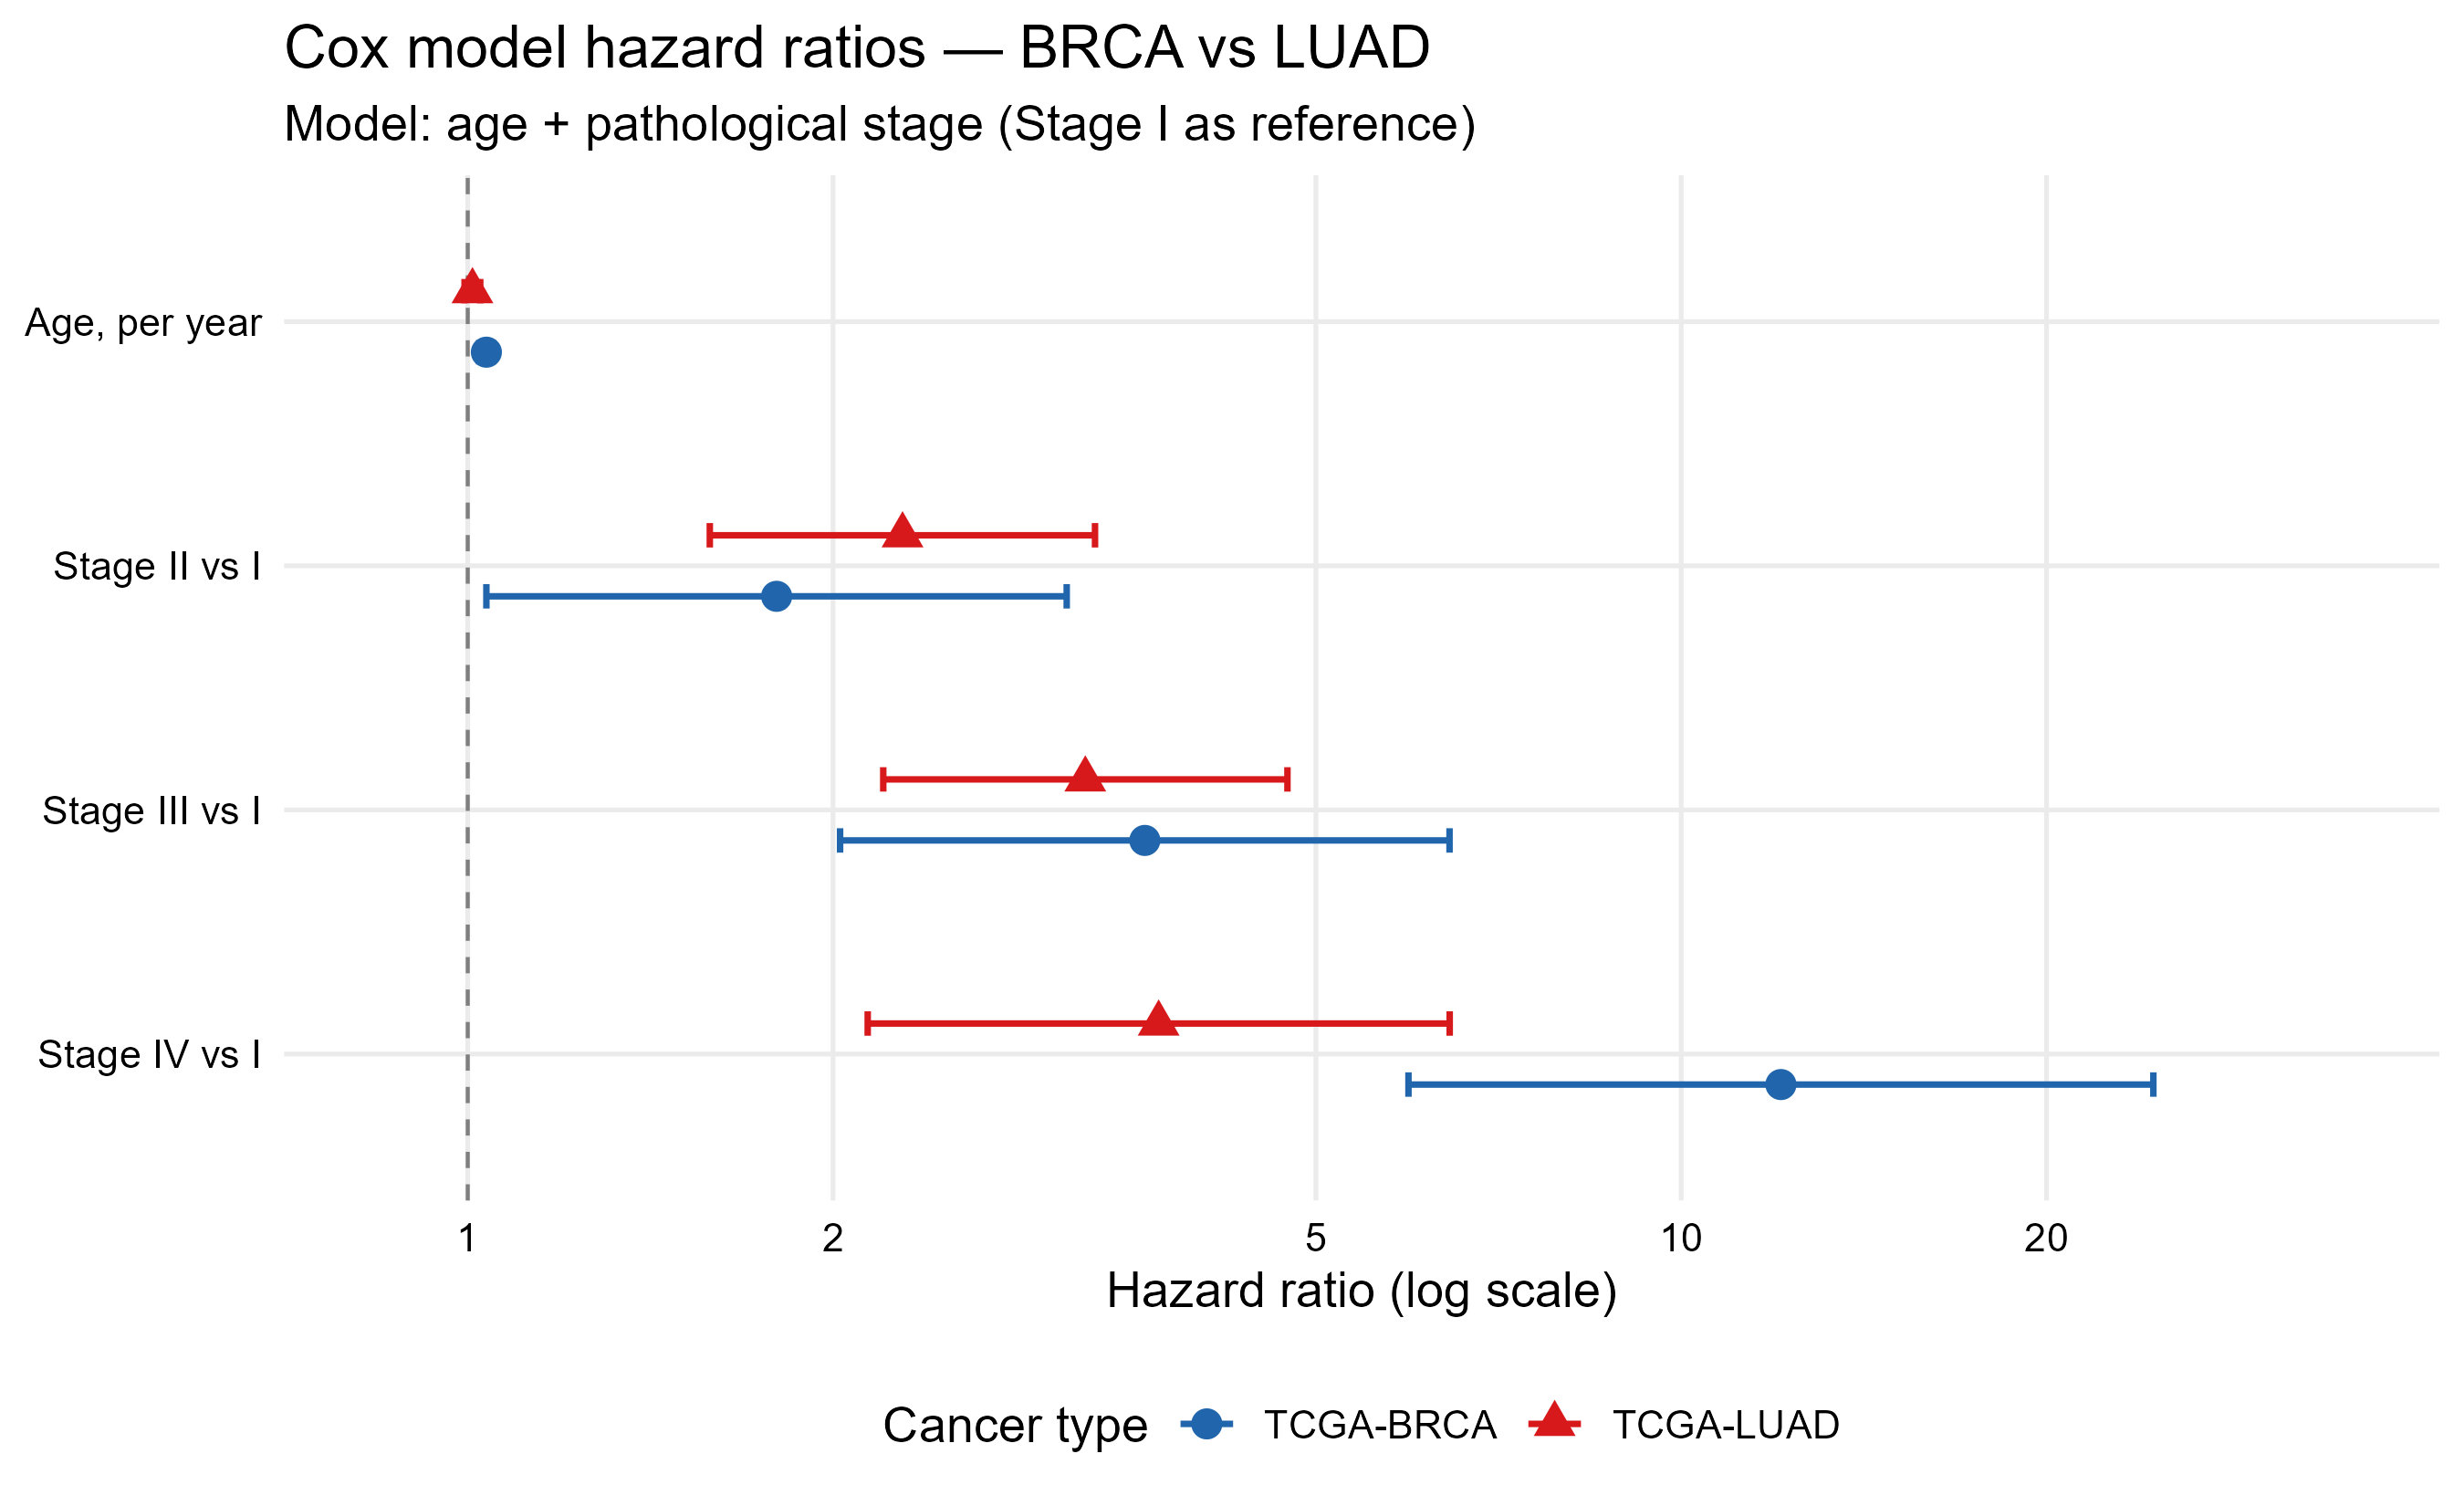

In [7]:
km_path  = FIG_DIR / "multicancer_km_comparison.png"
cox_path = FIG_DIR / "multicancer_cox_comparison.png"

from IPython.display import Image, display as ipy_display

if km_path.exists():
    print("BRCA vs LUAD — Kaplan-Meier comparison")
    ipy_display(Image(str(km_path)))
else:
    print("multicancer_km_comparison.png not found.")

if cox_path.exists():
    print("BRCA vs LUAD — Cox forest plot comparison")
    ipy_display(Image(str(cox_path)))
else:
    print("multicancer_cox_comparison.png not found.")